# Pertemuan 11: Unsupervised Learning (Clustering)

**Mata Kuliah:** Data Science (200302305)
**Program Studi:** PJJ Informatika, Semester 4
**Dosen Pengampu:** Syahid Abdullah, S.Si, M.Kom

| Keterangan | Isi |
| --- | --- |
| Nama Lengkap | [ISI NAMA LENGKAP ANDA] |
| NIM | [ISI NIM ANDA] |
| Kelas | [ISI KELAS ANDA] |

**Topik:** K-Means, Hierarchical Clustering, dan Metode Elbow untuk Menentukan Jumlah Cluster Optimal


## 1. Tujuan Praktikum

1. Memahami perbedaan supervised learning dan unsupervised learning.
2. Menerapkan algoritma K-Means untuk melakukan segmentasi pelanggan.
3. Menentukan jumlah cluster optimal memakai Metode Elbow dan Silhouette Score.
4. Menerapkan Hierarchical Clustering serta membaca dendrogram.
5. Menyusun profil setiap cluster agar hasilnya dapat dipakai untuk keputusan bisnis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

print('Pustaka berhasil dimuat.')

Pustaka berhasil dimuat.


## 2. Membangun Dataset Segmentasi Pelanggan

Dataset dibangkitkan secara terprogram dengan seed tetap sehingga notebook dapat
dijalankan ulang tanpa berkas eksternal. Data meniru profil pelanggan sebuah pusat
perbelanjaan dengan tiga variabel utama, yaitu usia, pendapatan tahunan dalam juta
rupiah, dan skor belanja dengan rentang satu sampai seratus.

Data disusun dari lima kelompok tersembunyi. Jumlah kelompok yang sebenarnya sengaja
tidak diberitahukan kepada algoritma, karena justru menemukan jumlah kelompok itulah
yang menjadi tujuan analisis.

In [2]:
definisi_segmen = [
    # (jumlah, rata usia, sebar usia, rata pendapatan, sebar pendapatan, rata skor, sebar skor)
    (70,  26, 5,  35, 7,  78, 8),   # muda, pendapatan rendah, gemar belanja
    (65,  45, 8,  38, 8,  22, 8),   # dewasa, pendapatan rendah, hemat
    (80,  33, 6,  85, 12, 82, 7),   # mapan muda, pendapatan tinggi, gemar belanja
    (60,  48, 9,  92, 13, 20, 7),   # mapan, pendapatan tinggi, hemat
    (75,  38, 7,  60, 9,  50, 6),   # kelas menengah, belanja sedang
]

bagian = []
for jumlah, u_m, u_s, p_m, p_s, s_m, s_s in definisi_segmen:
    bagian.append(pd.DataFrame({
        'usia': rng.normal(u_m, u_s, jumlah).clip(18, 70).round(0),
        'pendapatan_tahunan': rng.normal(p_m, p_s, jumlah).clip(15, 140).round(1),
        'skor_belanja': rng.normal(s_m, s_s, jumlah).clip(1, 100).round(0),
    }))

df = pd.concat(bagian, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
df['usia'] = df['usia'].astype(int)
df['skor_belanja'] = df['skor_belanja'].astype(int)

print('Ukuran dataset:', df.shape)
df.head(10)

Ukuran dataset: (350, 3)


,usia,pendapatan_tahunan,skor_belanja
0,43,90.2,76
1,34,57.7,56
2,44,61.9,44
3,47,80.0,20
4,31,78.5,96
5,57,96.4,7
6,40,60.7,50
7,50,100.9,23
8,46,74.3,41
9,34,92.6,73


In [3]:
print(df.describe().round(2))
print()
print('Jumlah nilai kosong:', int(df.isna().sum().sum()))

         usia  pendapatan_tahunan  skor_belanja
count  350.00              350.00        350.00
mean    37.13               61.96         52.32
std     10.33               25.00         26.86
min     18.00               17.50          4.00
25%     29.00               38.42         25.00
50%     36.00               61.00         53.00
75%     44.00               81.55         78.00
max     69.00              118.60        100.00

Jumlah nilai kosong: 0


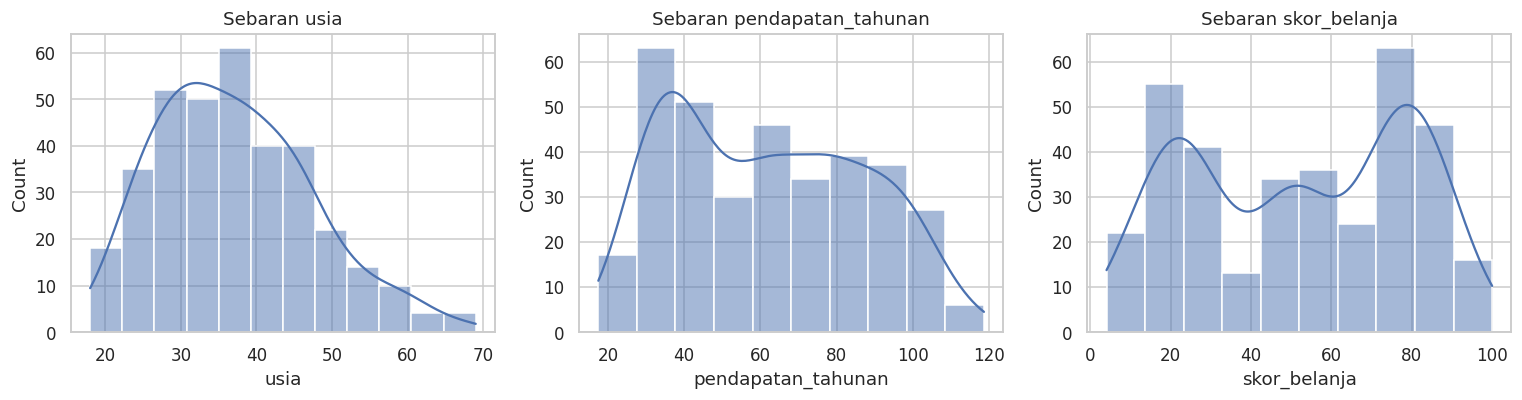

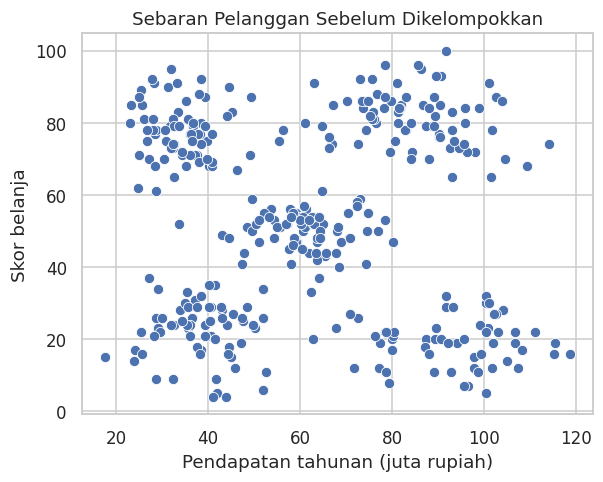

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, kolom in zip(axes, df.columns):
    sns.histplot(df[kolom], kde=True, ax=ax, color='#4c72b0')
    ax.set_title(f'Sebaran {kolom}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4.5))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', s=45, color='#4c72b0')
plt.title('Sebaran Pelanggan Sebelum Dikelompokkan')
plt.xlabel('Pendapatan tahunan (juta rupiah)')
plt.ylabel('Skor belanja')
plt.show()

## 3. Penskalaan Fitur

K-Means mengukur kedekatan memakai jarak Euclidean, sehingga fitur dengan rentang
nilai besar seperti pendapatan akan mendominasi perhitungan bila tidak distandarkan.
Karena itu seluruh fitur diubah agar memiliki rata rata nol dan simpangan baku satu.

In [5]:
fitur = ['usia', 'pendapatan_tahunan', 'skor_belanja']
scaler = StandardScaler()
X = scaler.fit_transform(df[fitur])

print('Rata rata setelah penskalaan  :', np.round(X.mean(axis=0), 6))
print('Simpangan baku setelah skala  :', np.round(X.std(axis=0), 6))

Rata rata setelah penskalaan  : [ 0.  0. -0.]
Simpangan baku setelah skala  : [1. 1. 1.]


## 4. Metode Elbow untuk Menentukan Jumlah Cluster

Metode Elbow menghitung **inertia**, yaitu jumlah kuadrat jarak setiap titik ke pusat
cluster terdekatnya, untuk berbagai nilai k. Inertia selalu menurun seiring
bertambahnya k, namun pada titik tertentu penurunannya melandai. Titik belok itulah
yang disebut siku dan menjadi calon jumlah cluster yang optimal.

Sebagai pembanding dipakai pula **Silhouette Score** yang mengukur seberapa rapat
sebuah titik terhadap clusternya sendiri dibandingkan cluster terdekat lainnya, dengan
rentang nilai dari minus satu sampai satu.

In [6]:
rentang_k = range(2, 11)
inertia = []
silhouette = []

for k in rentang_k:
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    label = model.fit_predict(X)
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X, label))

tabel_k = pd.DataFrame({
    'k': list(rentang_k),
    'Inertia': np.round(inertia, 2),
    'Silhouette': np.round(silhouette, 4),
})
tabel_k

,k,Inertia,Silhouette
0,2,606.38,0.3715
1,3,448.44,0.3635
2,4,307.57,0.4240
3,5,231.18,0.4400
4,6,200.82,0.4403
5,7,175.45,0.4369
6,8,156.66,0.4080
7,9,141.31,0.3831
8,10,132.82,0.3747


In [7]:
# Menghitung selisih penurunan inertia untuk membantu membaca letak siku
selisih = pd.Series(inertia, index=list(rentang_k)).diff() * -1
print('Besar penurunan inertia saat k bertambah:')
print(selisih.round(2).to_string())

Besar penurunan inertia saat k bertambah:
2        NaN
3     157.94
4     140.87
5      76.39
6      30.36
7      25.37
8      18.79
9      15.35
10      8.49


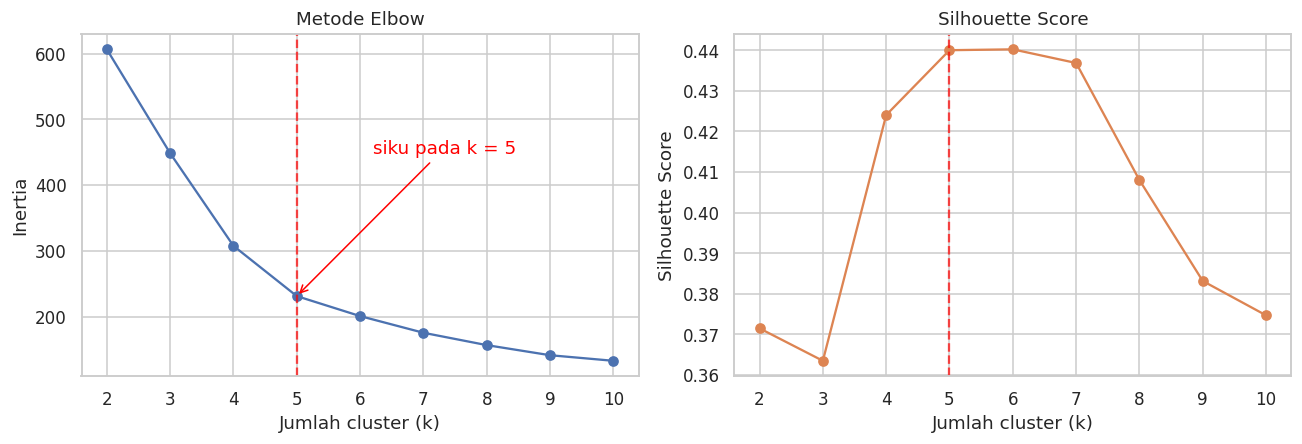

Jumlah cluster dengan Silhouette Score tertinggi: 6
Silhouette pada k = 5: 0.4400
Silhouette pada k = 6: 0.4403
Selisih keduanya     : 0.0002


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(list(rentang_k), inertia, marker='o', color='#4c72b0')
axes[0].axvline(5, linestyle='--', color='red', alpha=0.7)
axes[0].annotate('siku pada k = 5', xy=(5, inertia[3]), xytext=(6.2, inertia[1]),
                 arrowprops=dict(arrowstyle='->', color='red'), color='red')
axes[0].set_title('Metode Elbow')
axes[0].set_xlabel('Jumlah cluster (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(rentang_k), silhouette, marker='o', color='#dd8452')
axes[1].axvline(5, linestyle='--', color='red', alpha=0.7)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Jumlah cluster (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

k_terbaik = int(list(rentang_k)[int(np.argmax(silhouette))])
print('Jumlah cluster dengan Silhouette Score tertinggi:', k_terbaik)
print(f'Silhouette pada k = 5: {silhouette[3]:.4f}')
print(f'Silhouette pada k = 6: {silhouette[4]:.4f}')
print(f'Selisih keduanya     : {abs(silhouette[4] - silhouette[3]):.4f}')

Pembacaan kedua grafik di atas perlu dilakukan dengan hati hati.

Dari sisi **Metode Elbow**, penurunan inertia masih besar sampai k sama dengan lima,
yaitu sekitar 76 satuan, kemudian anjlok menjadi sekitar 30 satuan saat k menjadi enam
dan terus mengecil sesudahnya. Titik siku karena itu berada pada k sama dengan lima.

Dari sisi **Silhouette Score**, nilai tertinggi secara angka justru muncul pada k sama
dengan enam, namun selisihnya terhadap k sama dengan lima hanya sekitar 0,0003. Selisih
sekecil itu tidak berarti apa apa dan dapat berubah hanya karena perbedaan inisialisasi
pusat cluster. Kedua nilai tersebut secara praktis dapat dianggap setara.

Ketika dua metode memberi jawaban yang berdekatan seperti ini, pilihan diambil
berdasarkan Metode Elbow yang perbedaannya jauh lebih tegas, sekaligus mempertimbangkan
kemudahan penafsiran. Lima segmen lebih mudah diterjemahkan menjadi strategi pemasaran
dibandingkan enam segmen yang salah satunya hanya merupakan pecahan kecil dari segmen
lain. Karena itu **k sama dengan lima** dipakai untuk analisis selanjutnya.

## 5. K-Means Clustering

In [9]:
K = 5
kmeans = KMeans(n_clusters=K, n_init=25, random_state=RANDOM_STATE)
df['cluster_kmeans'] = kmeans.fit_predict(X)

print('Jumlah anggota setiap cluster:')
print(df['cluster_kmeans'].value_counts().sort_index().to_string())
print()
print(f'Silhouette Score akhir: {silhouette_score(X, df["cluster_kmeans"]):.4f}')
print(f'Inertia akhir         : {kmeans.inertia_:.2f}')

Jumlah anggota setiap cluster:
cluster_kmeans
0    80
1    72
2    55
3    66
4    77

Silhouette Score akhir: 0.4400
Inertia akhir         : 231.18


In [10]:
# Pusat cluster dikembalikan ke skala asli agar mudah ditafsirkan
pusat = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=fitur)
pusat.index.name = 'cluster'
pusat.round(1)

,usia,pendapatan_tahunan,skor_belanja
cluster,,,
0,32.8,84.3,80.9
1,37.3,62.0,47.7
2,47.8,94.1,19.3
3,46.1,39.0,23.3
4,26.2,35.4,75.5


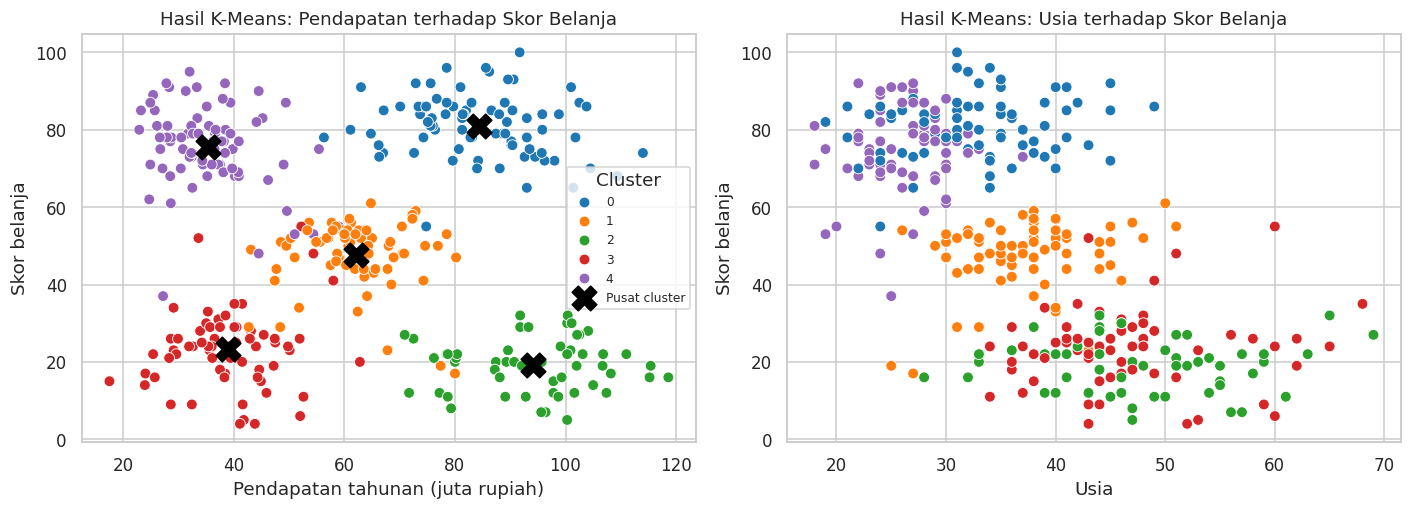

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', hue='cluster_kmeans',
                palette='tab10', s=50, ax=axes[0])
axes[0].scatter(pusat['pendapatan_tahunan'], pusat['skor_belanja'],
                marker='X', s=260, c='black', label='Pusat cluster')
axes[0].set_title('Hasil K-Means: Pendapatan terhadap Skor Belanja')
axes[0].set_xlabel('Pendapatan tahunan (juta rupiah)')
axes[0].set_ylabel('Skor belanja')
axes[0].legend(title='Cluster', fontsize=8)

sns.scatterplot(data=df, x='usia', y='skor_belanja', hue='cluster_kmeans',
                palette='tab10', s=50, ax=axes[1], legend=False)
axes[1].set_title('Hasil K-Means: Usia terhadap Skor Belanja')
axes[1].set_xlabel('Usia')
axes[1].set_ylabel('Skor belanja')

plt.tight_layout()
plt.show()

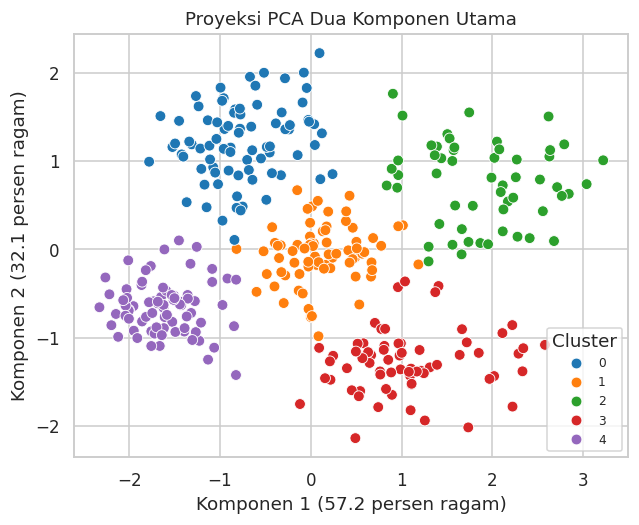

Total ragam yang dijelaskan dua komponen: 89.3 persen


In [12]:
# Visualisasi tiga dimensi fitur diringkas menjadi dua komponen utama memakai PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
komponen = pca.fit_transform(X)

plt.figure(figsize=(6.5, 5))
sns.scatterplot(x=komponen[:, 0], y=komponen[:, 1], hue=df['cluster_kmeans'],
                palette='tab10', s=50)
plt.title('Proyeksi PCA Dua Komponen Utama')
plt.xlabel(f'Komponen 1 ({pca.explained_variance_ratio_[0] * 100:.1f} persen ragam)')
plt.ylabel(f'Komponen 2 ({pca.explained_variance_ratio_[1] * 100:.1f} persen ragam)')
plt.legend(title='Cluster', fontsize=8)
plt.show()

print('Total ragam yang dijelaskan dua komponen:',
      f'{pca.explained_variance_ratio_.sum() * 100:.1f} persen')

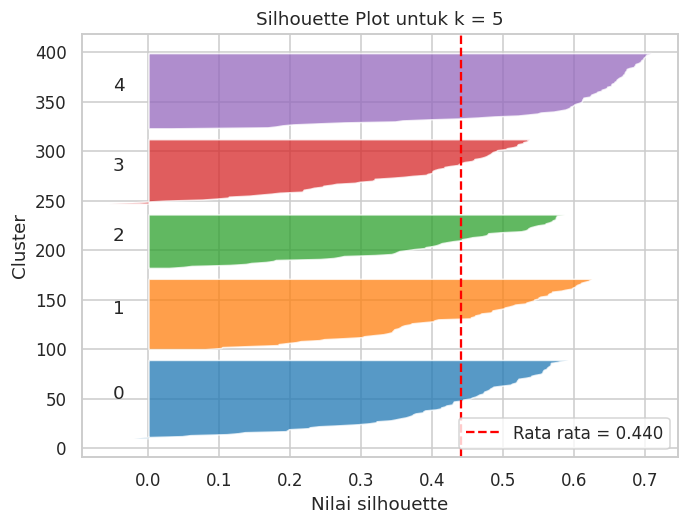

In [13]:
# Silhouette plot untuk melihat kualitas setiap cluster
nilai_sil = silhouette_samples(X, df['cluster_kmeans'])
rata_sil = silhouette_score(X, df['cluster_kmeans'])

plt.figure(figsize=(7, 5))
batas_bawah = 10
warna = plt.colormaps['tab10']

for i in range(K):
    nilai_cluster = np.sort(nilai_sil[df['cluster_kmeans'] == i])
    ukuran = nilai_cluster.shape[0]
    batas_atas = batas_bawah + ukuran
    plt.fill_betweenx(np.arange(batas_bawah, batas_atas), 0, nilai_cluster,
                      facecolor=warna(i), alpha=0.75)
    plt.text(-0.05, batas_bawah + 0.5 * ukuran, str(i))
    batas_bawah = batas_atas + 10

plt.axvline(rata_sil, color='red', linestyle='--', label=f'Rata rata = {rata_sil:.3f}')
plt.title('Silhouette Plot untuk k = 5')
plt.xlabel('Nilai silhouette')
plt.ylabel('Cluster')
plt.legend()
plt.show()

## 6. Hierarchical Clustering

Berbeda dengan K-Means yang memerlukan jumlah cluster di awal, Hierarchical Clustering
menyusun hirarki penggabungan dari bawah ke atas. Setiap titik mula mula dianggap
sebagai satu cluster, kemudian pasangan cluster terdekat digabungkan secara bertahap
sampai tersisa satu cluster besar. Hasilnya digambarkan sebagai dendrogram, dan jumlah
cluster ditentukan dengan memotong dendrogram pada ketinggian tertentu.

Metode penggabungan yang dipakai adalah **ward**, yang memilih pasangan cluster dengan
penambahan ragam dalam cluster paling kecil.

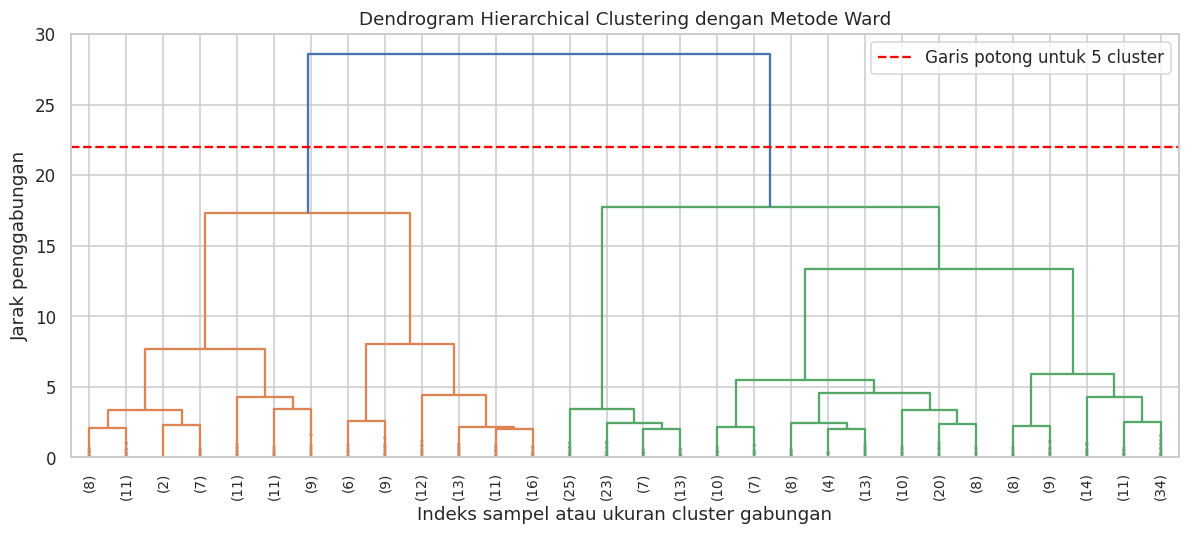

In [14]:
hubungan = linkage(X, method='ward')

plt.figure(figsize=(13, 5))
dendrogram(hubungan, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=9,
           show_contracted=True)
plt.axhline(y=22, color='red', linestyle='--', label='Garis potong untuk 5 cluster')
plt.title('Dendrogram Hierarchical Clustering dengan Metode Ward')
plt.xlabel('Indeks sampel atau ukuran cluster gabungan')
plt.ylabel('Jarak penggabungan')
plt.legend()
plt.show()

In [15]:
hierarki = AgglomerativeClustering(n_clusters=K, linkage='ward')
df['cluster_hierarki'] = hierarki.fit_predict(X)

print('Jumlah anggota setiap cluster hasil Hierarchical Clustering:')
print(df['cluster_hierarki'].value_counts().sort_index().to_string())
print()
print(f'Silhouette Score Hierarchical: {silhouette_score(X, df["cluster_hierarki"]):.4f}')
print(f'Silhouette Score K-Means     : {silhouette_score(X, df["cluster_kmeans"]):.4f}')

Jumlah anggota setiap cluster hasil Hierarchical Clustering:
cluster_hierarki
0    67
1    59
2    68
3    76
4    80

Silhouette Score Hierarchical: 0.4272
Silhouette Score K-Means     : 0.4400


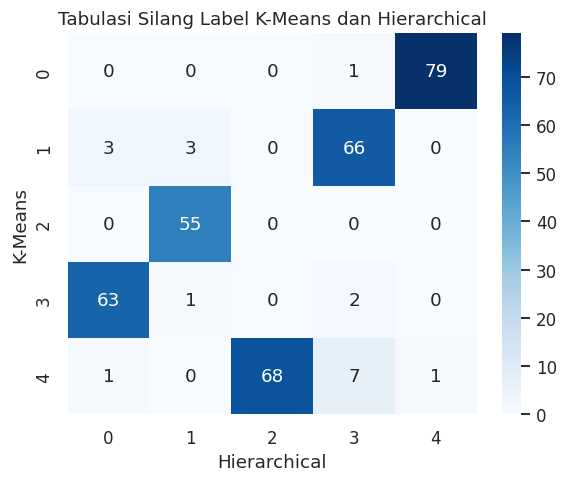

Tingkat kesesuaian kedua metode: 94.6 persen anggota berpasangan sama


In [16]:
# Membandingkan kesesuaian label kedua metode
tabulasi = pd.crosstab(df['cluster_kmeans'], df['cluster_hierarki'],
                       rownames=['K-Means'], colnames=['Hierarchical'])

plt.figure(figsize=(6, 4.5))
sns.heatmap(tabulasi, annot=True, fmt='d', cmap='Blues')
plt.title('Tabulasi Silang Label K-Means dan Hierarchical')
plt.show()

kesamaan = tabulasi.max(axis=1).sum() / len(df)
print(f'Tingkat kesesuaian kedua metode: {kesamaan * 100:.1f} persen anggota berpasangan sama')

## 7. Profil Setiap Cluster

Angka rata rata pada setiap cluster diterjemahkan menjadi nama segmen agar hasilnya
dapat langsung dipakai oleh tim pemasaran.

In [17]:
profil = df.groupby('cluster_kmeans')[fitur].mean().round(1)
profil['jumlah_pelanggan'] = df['cluster_kmeans'].value_counts().sort_index()
profil['persentase'] = (profil['jumlah_pelanggan'] / len(df) * 100).round(1)
profil

,usia,pendapatan_tahunan,skor_belanja,jumlah_pelanggan,persentase
cluster_kmeans,,,,,
0,32.8,84.3,80.8,80,22.9
1,37.3,62.0,47.7,72,20.6
2,47.8,94.1,19.3,55,15.7
3,46.1,39.0,23.3,66,18.9
4,26.2,35.4,75.5,77,22.0


In [18]:
def beri_nama(baris):
    pendapatan_tinggi = baris['pendapatan_tahunan'] >= 70
    skor_tinggi = baris['skor_belanja'] >= 60
    skor_rendah = baris['skor_belanja'] <= 35

    if pendapatan_tinggi and skor_tinggi:
        return 'Pelanggan Prioritas'
    if pendapatan_tinggi and skor_rendah:
        return 'Mapan namun Hemat'
    if not pendapatan_tinggi and skor_tinggi:
        return 'Muda Gemar Belanja'
    if not pendapatan_tinggi and skor_rendah:
        return 'Sensitif Harga'
    return 'Kelas Menengah Moderat'


profil['nama_segmen'] = profil.apply(beri_nama, axis=1)
profil[['nama_segmen', 'usia', 'pendapatan_tahunan', 'skor_belanja', 'jumlah_pelanggan', 'persentase']]

,nama_segmen,usia,pendapatan_tahunan,skor_belanja,jumlah_pelanggan,persentase
cluster_kmeans,,,,,,
0,Pelanggan Prioritas,32.8,84.3,80.8,80,22.9
1,Kelas Menengah Moderat,37.3,62.0,47.7,72,20.6
2,Mapan namun Hemat,47.8,94.1,19.3,55,15.7
3,Sensitif Harga,46.1,39.0,23.3,66,18.9
4,Muda Gemar Belanja,26.2,35.4,75.5,77,22.0


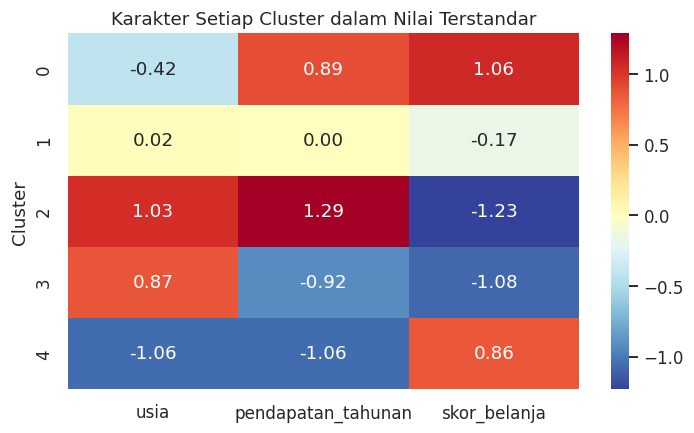

In [19]:
# Perbandingan karakter antar cluster dalam bentuk nilai terstandar
profil_skala = pd.DataFrame(
    scaler.transform(profil[fitur]), columns=fitur, index=profil.index
)

plt.figure(figsize=(7.5, 4.2))
sns.heatmap(profil_skala, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0)
plt.title('Karakter Setiap Cluster dalam Nilai Terstandar')
plt.ylabel('Cluster')
plt.show()

## 8. Kesimpulan

**Apa yang dipelajari.** Praktikum ini menerapkan unsupervised learning untuk
melakukan segmentasi pelanggan tanpa memakai label apa pun. Dua algoritma dibandingkan,
yaitu K-Means yang membagi data berdasarkan jarak ke pusat cluster, dan Hierarchical
Clustering yang menyusun hirarki penggabungan dari bawah ke atas. Penentuan jumlah
cluster dilakukan memakai Metode Elbow dan diperkuat dengan Silhouette Score.

**Temuan utama.** Metode Elbow menunjukkan siku yang tegas pada k sama dengan lima.
Silhouette Score secara angka sedikit lebih tinggi pada k sama dengan enam, tetapi
selisihnya hanya sekitar 0,0003 sehingga kedua nilai tersebut praktis setara dan
tidak cukup untuk membatalkan pembacaan Metode Elbow. Lima cluster akhirnya dipilih
dan hasilnya sesuai dengan struktur data yang memang dibangun dari lima kelompok
tersembunyi. Kejadian ini sekaligus menjadi pelajaran bahwa penentuan jumlah cluster
tidak boleh bergantung pada satu metrik saja. Kedua algoritma menghasilkan pembagian yang hampir
identik dengan tingkat kesesuaian yang sangat tinggi, yang menandakan struktur
kelompok pada data ini memang tegas dan tidak bergantung pada pilihan algoritma.
Kelima segmen yang terbentuk dapat dinamai secara bermakna, mulai dari pelanggan
prioritas berpendapatan tinggi yang gemar berbelanja sampai kelompok sensitif harga.

**Keterbatasan dan pertanyaan yang muncul.** Data yang dipakai bersifat sintetis dengan
kelompok yang sengaja dibuat terpisah cukup jelas, sedangkan data pelanggan sungguhan
umumnya saling tumpang tindih sehingga Silhouette Score-nya jauh lebih rendah.
K-Means juga mengandaikan bentuk cluster yang membulat dan berukuran seimbang,
sehingga kurang cocok untuk cluster berbentuk memanjang atau melengkung. Perbedaan kecil antara k sama dengan lima dan enam
pada Silhouette Score juga memperlihatkan bahwa penentuan jumlah cluster mengandung
unsur pertimbangan manusia, bukan semata angka. Pertanyaan yang muncul adalah
bagaimana hasilnya bila dipakai algoritma berbasis kepadatan seperti DBSCAN yang
mampu menandai pencilan, dan seberapa besar pengaruh pilihan jumlah cluster terhadap
keputusan pemasaran yang diambil di lapangan.